### Workbook for creating maps and graphics for FOSS4G manuscript
Week of February 2, 2026 <br>
Author: Adele Birkenes

In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

Task 1: Set synced & unsynced file paths, read in needs assessment data & village boundaries, ensure CRSs match

In [3]:
# Set synced data path
synced_path = "../../synced-data/population-exploration"

# Set unsynced data path
unsynced_path = "../../unsynced-data/"

# Set needs assessment file path
needs_assessment_fp = os.path.join(synced_path, "Rwanda Sites with All Population Fields_Exported 2025.04.11.csv")

# Read the .csv file into a dataframe with an encoding that accommodates special characters
needs_assessment_df = pd.read_csv(needs_assessment_fp, encoding='ISO-8859-1')

# Create gdf from needs assessment data, using longitude and latitude columns to create Point geometries
geometry = [Point(xy) for xy in zip(needs_assessment_df['Bridge Opportunity: GPS (Longitude)'], needs_assessment_df['Bridge Opportunity: GPS (Latitude)'])]
needs_assessment = gpd.GeoDataFrame(needs_assessment_df, geometry=geometry, crs="EPSG:4326")

In [4]:
# Set village boundaries file path
village_boundaries_fp = os.path.join(synced_path, "Rwanda Village Boundaries/Village.shp")

# Read shp into a gdf
village_boundaries = gpd.read_file(village_boundaries_fp)

In [5]:
# Set needs assessment gdf CRS to that of village boundaries
needs_assessment = needs_assessment.to_crs(village_boundaries.crs)
print(needs_assessment.crs)

PROJCS["TM_Rwanda",GEOGCS["ITRF2005",DATUM["International_Terrestrial_Reference_Frame_2005",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6896"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",30],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",500000],PARAMETER["false_northing",5000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


Task 2: Dissolve village boundaries gdf to create admin 1-4 boundaries

In [6]:
# Dissolve village boundaries gdf to create gdfs for admin 1-4 boundaries
def dissolve_boundaries(admin_level, village_boundaries=village_boundaries):
    # Dissolve the village boundaries by the specified admin level
    dissolved_boundaries = village_boundaries.dissolve(by=admin_level)
    dissolved_boundaries.reset_index(inplace=True)

    # Remove unneeded admin columns (e.g., 'Village_ID' for admin level 4)
    if admin_level == 'Cell_ID':
        dissolved_boundaries.drop(columns=['Village_ID'], inplace=True)
    if admin_level == 'Sector_ID':
        dissolved_boundaries.drop(columns=['Village_ID', 'Cell_ID'], inplace=True)
    if admin_level == 'Dist_ID':
        dissolved_boundaries.drop(columns=['Village_ID', 'Cell_ID', 'Sector_ID'], inplace=True)
    elif admin_level == 'Prov_ID':
        dissolved_boundaries.drop(columns=['Village_ID', 'Cell_ID', 'Sector_ID', 'Distr_ID'], inplace=True)

    return dissolved_boundaries

admin_1_boundaries = dissolve_boundaries(admin_level='Prov_ID')
admin_2_boundaries = dissolve_boundaries(admin_level='Distr_ID')
admin_3_boundaries = dissolve_boundaries(admin_level='Sector_ID')
admin_4_boundaries = dissolve_boundaries(admin_level='Cell_ID')

Task 3: Create a map of sites covered by needs assessments, classifying the points according to "Bridge Opportunity: Stage"

In [7]:
# Get unique values for "Bridge Opportunity: Stage" column in needs assessment gdf
needs_assessment["Bridge Opportunity: Stage"].unique()

array(['Rejected', 'Complete', 'Prospecting', 'Identified', 'Cancelled',
       'Under Construction', 'Confirmed'], dtype=object)

In [8]:
# Read in global admin 0 boundaries sourced from geoBoundaries (https://www.geoboundaries.org/globalDownloads.html)
world_fp = os.path.join(unsynced_path, "geoBoundariesCGAZ_ADM0/geoBoundariesCGAZ_ADM0.shp")
world = gpd.read_file(world_fp)

# Set world gdf CRS to that of village boundaries
world = world.to_crs(village_boundaries.crs)
print(world.crs)

PROJCS["TM_Rwanda",GEOGCS["ITRF2005",DATUM["International_Terrestrial_Reference_Frame_2005",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6896"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",30],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",500000],PARAMETER["false_northing",5000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [25]:
# Read in lakes vector data from Natural Earth
lakes_url = "https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip"
lakes = gpd.read_file(lakes_url)

# Set lakes gdf CRS to that of village boundaries
lakes = lakes.to_crs(village_boundaries.crs)
print(lakes.crs)

PROJCS["TM_Rwanda",GEOGCS["ITRF2005",DATUM["International_Terrestrial_Reference_Frame_2005",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6896"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",30],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",500000],PARAMETER["false_northing",5000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


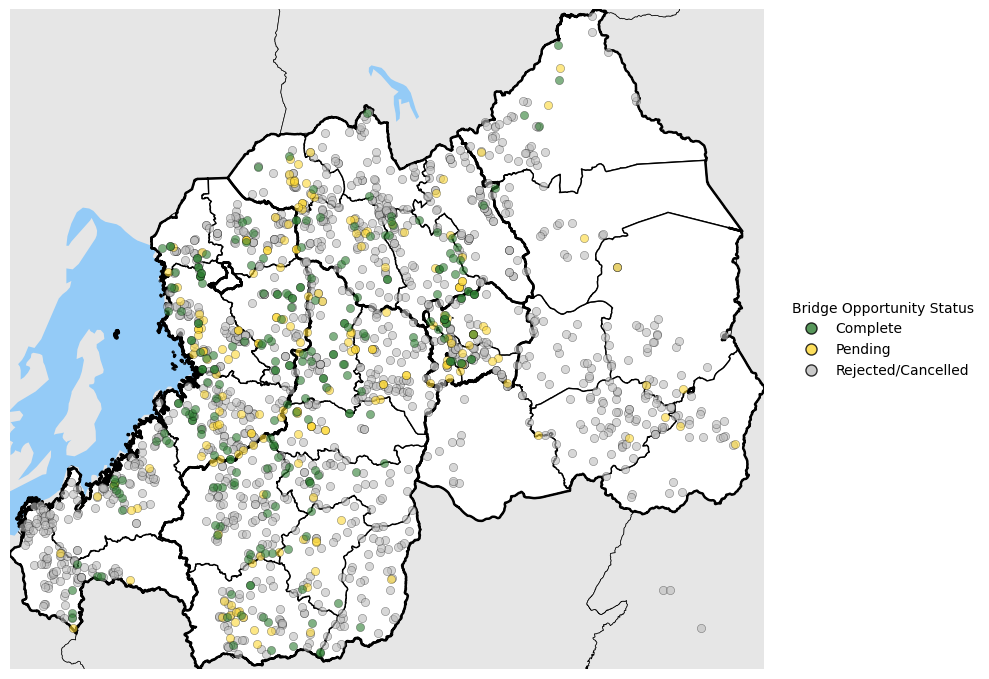

In [32]:
fig, ax = plt.subplots(figsize=(10, 10))

# =========================
# --- BASEMAP & BOUNDARIES
# =========================

# World base
world.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="black",
    linewidth=0.5,
    zorder=1
)

# Lakes
lakes.plot(
    ax=ax,
    color="#94cbf7",
    zorder=2
)

# Admin 2
admin_2_boundaries.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    alpha=1,
    linewidth=1,
    zorder=3
)

# Admin 1
admin_1_boundaries.plot(
    ax=ax,
    color="none",
    edgecolor="black",
    linewidth=1.8,
    zorder=4
)

# =========================
# --- STAGE RECLASSIFICATION
# =========================

# Stage → visual class mapping
stage_class = {
    "Rejected": "Rejected/Cancelled",
    "Cancelled": "Rejected/Cancelled",
    "Prospecting": "Pending",
    "Identified": "Pending",
    "Confirmed": "Pending",
    "Under Construction": "Pending",
    "Complete": "Complete"
}

# Visual class → color mapping
class_colors = {
    "Complete": "#2e7d32",            # green
    "Pending": "#fdd835",             # yellow
    "Rejected/Cancelled": "#bdbdbd"   # gray
}

plot_classes = ["Rejected/Cancelled", "Pending", "Complete"]
legend_order = ["Complete", "Pending", "Rejected/Cancelled"]

# =========================
# --- PLOT BRIDGES
# =========================

for visual_class in plot_classes:
    subset = needs_assessment[
        needs_assessment["Bridge Opportunity: Stage"]
        .map(stage_class) == visual_class
    ]

    if subset.empty:
        continue

    subset.plot(
        ax=ax,
        color=class_colors[visual_class],
        markersize=35,
        alpha=0.6,           # semi-transparent
        edgecolor="black",   # helps separate overlaps
        linewidth=0.3,
        zorder=5
    )

# =========================
# --- ZOOM TO RWANDA
# =========================

minx, miny, maxx, maxy = admin_1_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# =========================
# --- LEGEND
# =========================

from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=label,
        markerfacecolor=class_colors[label],
        markeredgecolor="black",
        markersize=8,
        alpha=0.8
    )
    for label in legend_order
]

ax.legend(
    handles=legend_elements,
    title="Bridge Opportunity Status",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# =========================
# --- FINAL FORMATTING
# =========================

ax.axis("off")
plt.tight_layout()
plt.show()

Task 4: Create a map of sites covered by catchment surveys

In [34]:
# Set catchment data path
catchment_path = "../../synced-data/catchment-analysis"

# Read in bridge sites
bridge_sites_fp = os.path.join(catchment_path, "Rwanda_catchment_bridge_sites.csv")
bridge_sites_df = pd.read_csv(bridge_sites_fp, encoding='ISO-8859-1') # Note: This encoding accommodates special characters)

bridge_sites_df

,Bridge Name,Project Code,Lat,Long,Research Bridge,Bridge Completion Date,Total Surveys,Wave 1,Wave 2,Wave 3,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,Gasasa,1013460,-1.953730,29.54198,Yes,"May 19, 2021",595,"October, 2021","February, 2022",April 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Muhembe,1007425,-1.824870,29.61382,Yes,"May 19, 2021",458,"October, 2021","December, 2021",March 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mutiwingoma,1007481,-2.363733,29.55353,Yes,"November 6, 2020",488,"November, 2021","February, 2022","May, 2022",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Nyarusange,1014269,-1.894840,29.99693,Yes,"March 4, 2021","1,127","September, 2021",Nov 2021,"February, 2022",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Rugeshi,1013459,-1.960380,29.54036,Yes,"May 31, 2021","1,194","October, 2021",Dec 2021,March 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Convert bridge sites dataframe to geodataframe that has custom Rwanda TM CRS copied from village boundaries geodataframe
def map_bridges(bridges, bridges_lat, bridges_lon, village_boundaries):

    # Check CRS of village boundaries gdf
    print(f'The CRS of the village boundaries gdf is: {village_boundaries.crs}')

    # Create lat/lon variables
    lon = bridges[bridges_lon]
    lat = bridges[bridges_lat]

    # Create gdf of bridges data by converting lat/lon values to list of Shapely Point objects
    bridge_points = gpd.GeoDataFrame(bridges, geometry=gpd.points_from_xy(x=lon, y=lat), crs='EPSG:4326')

    # Set CRS of bridges gdf to CRS of village boundaries gdf
    bridge_points.to_crs(village_boundaries.crs, inplace=True)

    # Check that reprojection was successful
    print(f'The CRS of the bridges gdf is: {bridge_points.crs}')
    
    return bridge_points

bridge_points = map_bridges(bridges = bridge_sites_df,
                            bridges_lat = "Lat",
                            bridges_lon = "Long",
                            village_boundaries = village_boundaries)

The CRS of the village boundaries gdf is: PROJCS["TM_Rwanda",GEOGCS["ITRF2005",DATUM["International_Terrestrial_Reference_Frame_2005",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6896"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",30],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",500000],PARAMETER["false_northing",5000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The CRS of the bridges gdf is: PROJCS["TM_Rwanda",GEOGCS["ITRF2005",DATUM["International_Terrestrial_Reference_Frame_2005",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6896"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",30],PARAMETER["scale_factor",0.9999],PARAMETER["false_

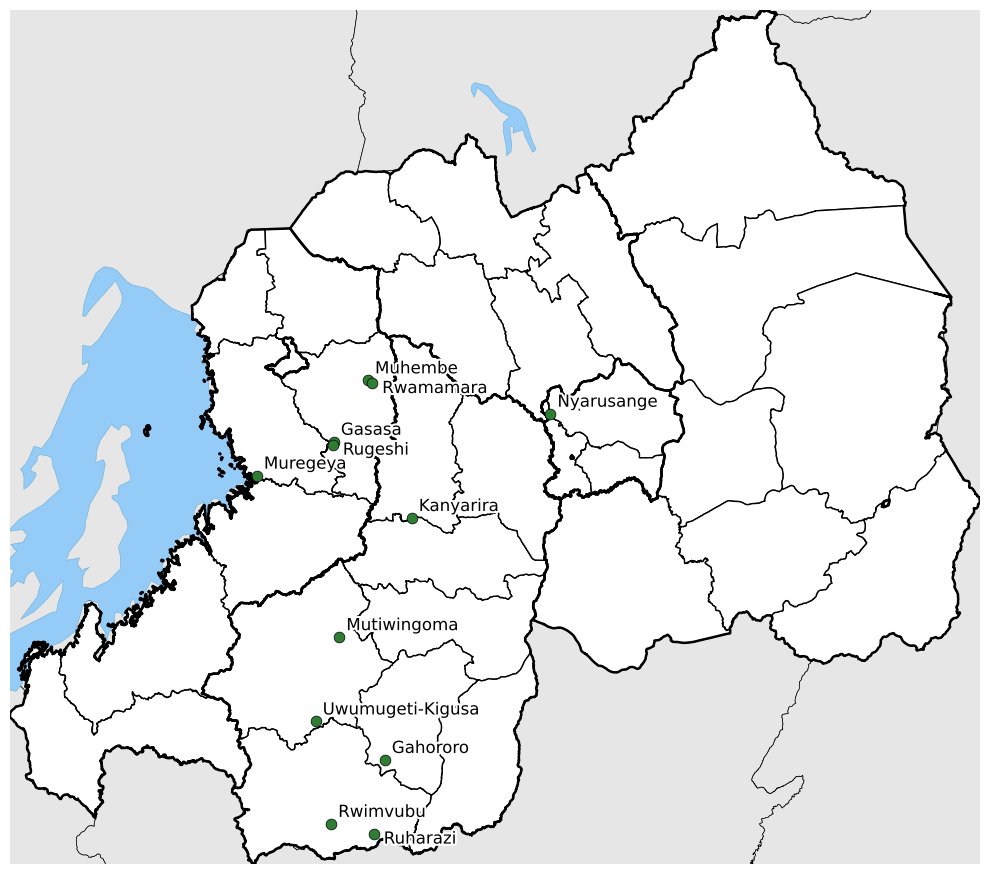

In [52]:
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(10, 10))

# =========================
# --- BASEMAP & BOUNDARIES
# =========================

# World
world.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="black",
    linewidth=0.5,
    zorder=1
)

# Lakes
lakes = lakes.to_crs(world.crs)
lakes.plot(
    ax=ax,
    color="#94cbf7",
    edgecolor="#6baed6",
    linewidth=0.4,
    zorder=2
)

# Admin 2
admin_2_boundaries.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=1,
    alpha=1,
    zorder=3
)

# Admin 1
admin_1_boundaries.plot(
    ax=ax,
    color="none",
    edgecolor="black",
    linewidth=1.8,
    zorder=4
)

# =========================
# --- PLOT 12 BRIDGES
# =========================

bridge_points = bridge_points.to_crs(world.crs)

bridge_points.plot(
    ax=ax,
    color="#2e7d32",
    markersize=60,
    edgecolor="black",
    linewidth=0.5,
    zorder=5
)

# =========================
# --- ADD LABELS
# =========================

for idx, row in bridge_points.iterrows():
    # Determine offset for this bridge
    if row["Bridge Name"] == "Rwamamara" or row["Bridge Name"] == "Rugeshi" or row["Bridge Name"] == "Ruharazi":
        offset = (7, -7)   # larger offset to avoid overlap
    else:
        offset = (5, 5)   # default small offset

    text = ax.annotate(
        text=row["Bridge Name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=offset,
        textcoords="offset points",
        fontsize=12,
        color="black",
        zorder=6
    )

    # Add a white halo around the text
    text.set_path_effects([
        pe.Stroke(linewidth=3, foreground="white"),  # halo
        pe.Normal()                                   # normal text on top
    ])

# =========================
# --- ZOOM TO RWANDA
# =========================

minx, miny, maxx, maxy = admin_1_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# =========================
# --- FINAL FORMATTING
# =========================

ax.axis("off")
plt.tight_layout()
plt.show()